# <center> Decoding Neural Activity
## <center> BIO_322
## <center> Defne Kaymak and S. Ceren Erdogan

## Project Description
In this project, we aim to decode neural activity recorded from mice performing a behavioral task.
During each trial, the animal may receive whisker stimulation (or no stimulation), may choose to lick or not lick, and may be in a GO or NOGO condition. These combinations define the trial type, which we treat as the label to predict.

The provided dataset contains neural activity features recorded from multiple brain areas across several time bins. Each row corresponds to a single trial, and each feature captures normalized neural firing activity in a specific population of neurons at a specific time point. The goal of the project is to build machine learning models that can accurately classify the trial type based solely on these neural signals.

This decoding problem is meaningful because different brain regions encode different aspects of sensory input, motor preparation, and behavioral decisions. By training machine learning models, we can identify whether the neural activity contains enough information to reliably distinguish between conditions such as GO vs NOGO trials, whisker stimulation vs no stimulation, and lick vs no-lick outcomes.

Following the project instructions, we performed data inspection, preprocessing, trained a linear baseline model (Logistic Regression), and then trained non-linear models (Random Forest and HistGradientBoosting) to capture more complex neural dynamics. Finally, we compared model performance and selected the best classifier for generating predictions on the held-out test set


## 0. Setup
### Imports, random seeds and global configuration.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)

## 1. Data inspection
### Load the training data, inspect basic structure, missing values, and class balance. 

In [36]:
df = pd.read_csv("train.csv")
df.head()
df.info()
df.describe()

print("Class balance (TRIAL_TYPE):")
print(df["TRIAL_TYPE"].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Columns: 1383 entries, session_id to TRIAL_TYPE
dtypes: float64(1380), int64(1), object(2)
memory usage: 46.5+ MB
Class balance (TRIAL_TYPE):
TRIAL_TYPE
NOGO W- nolick       0.199682
GO W- nolick         0.184479
NOGO W+ nolick       0.179941
no tone W+ nolick    0.165872
GO W+ lick           0.161334
GO W+ nolick         0.038348
no tone W+ lick      0.034037
NOGO W+ lick         0.019968
GO W- lick           0.015657
NOGO W- lick         0.000681
Name: proportion, dtype: float64


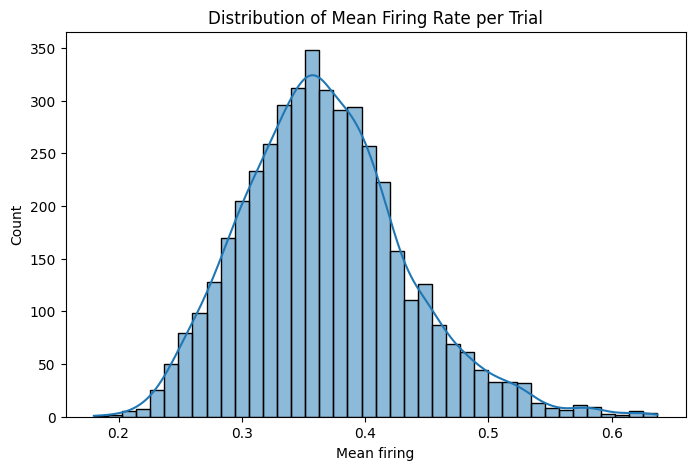

In [37]:
# Correctly select only neural features
drop_cols = ["TRIAL_TYPE", "session_id", "trial_number"]

activity_cols = [c for c in df.columns if c not in drop_cols]

X = df[activity_cols]

plt.figure(figsize=(8,5))
sns.histplot(X.mean(axis=1), bins=40, kde=True)
plt.title("Distribution of Mean Firing Rate per Trial")
plt.xlabel("Mean firing")
plt.ylabel("Count")
plt.show()

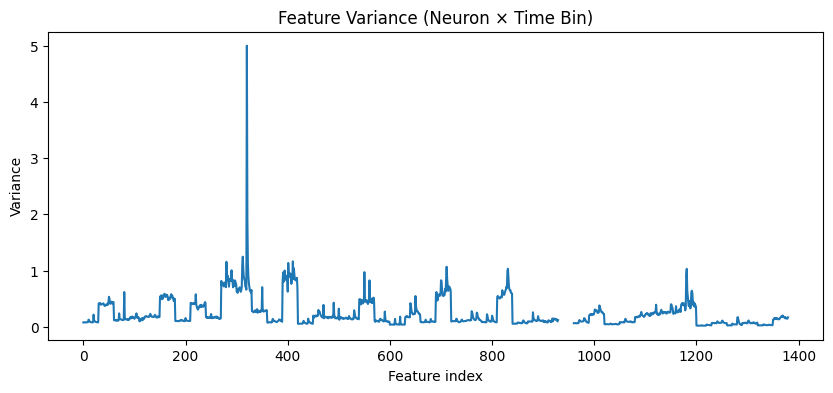

In [38]:
feature_variances = X.var()

plt.figure(figsize=(10,4))
plt.plot(feature_variances.values)
plt.title("Feature Variance (Neuron × Time Bin)")
plt.xlabel("Feature index")
plt.ylabel("Variance")
plt.show()

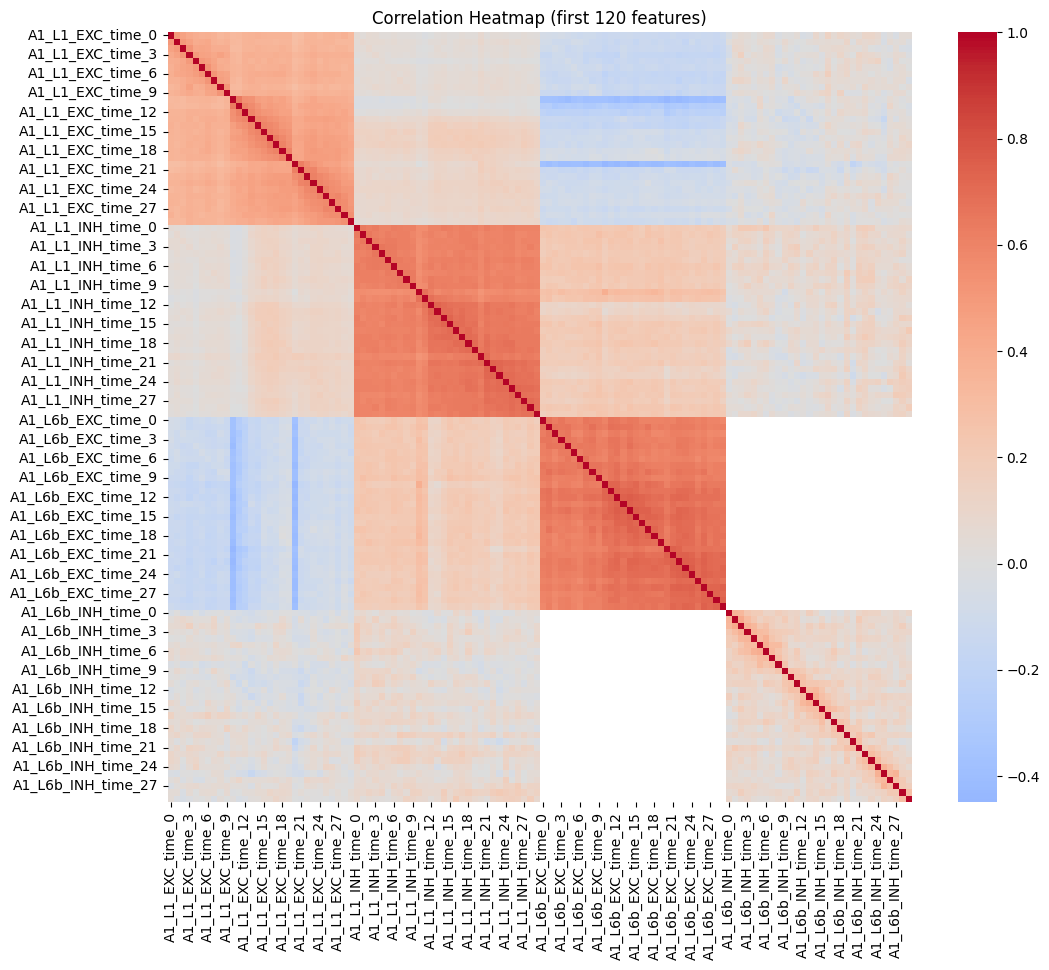

In [39]:
subset = X.iloc[:, :120]   # first 120 features to keep it readable

plt.figure(figsize=(12,10))
sns.heatmap(subset.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (first 120 features)")
plt.show()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/impute/_base.py:653: UserWarning: Skipping features without any observed values: ['wS2_L1_INH_time_0' 'wS2_L1_INH_time_1' 'wS2_L1_INH_time_2'
 'wS2_L1_INH_time_3' 'wS2_L1_INH_time_4' 'wS2_L1_INH_time_5'
 'wS2_L1_INH_time_6' 'wS2_L1_INH_time_7' 'wS2_L1_INH_time_8'
 'wS2_L1_INH_time_9' 'wS2_L1_INH_time_10' 'wS2_L1_INH_time_11'
 'wS2_L1_INH_time_12' 'wS2_L1_INH_time_13' 'wS2_L1_INH_time_14'
 'wS2_L1_INH_time_15' 'wS2_L1_INH_time_16' 'wS2_L1_INH_time_17'
 'wS2_L1_INH_time_18' 'wS2_L1_INH_time_19' 'wS2_L1_INH_time_20'
 'wS2_L1_INH_time_21' 'wS2_L1_INH_time_22' 'wS2_L1_INH_time_23'
 'wS2_L1_INH_time_24' 'wS2_L1_INH_time_25' 'wS2_L1_INH_time_26'
 'wS2_L1_INH_time_27' 'wS2_L1_INH_time_28' 'wS2_L1_INH_time_29']. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


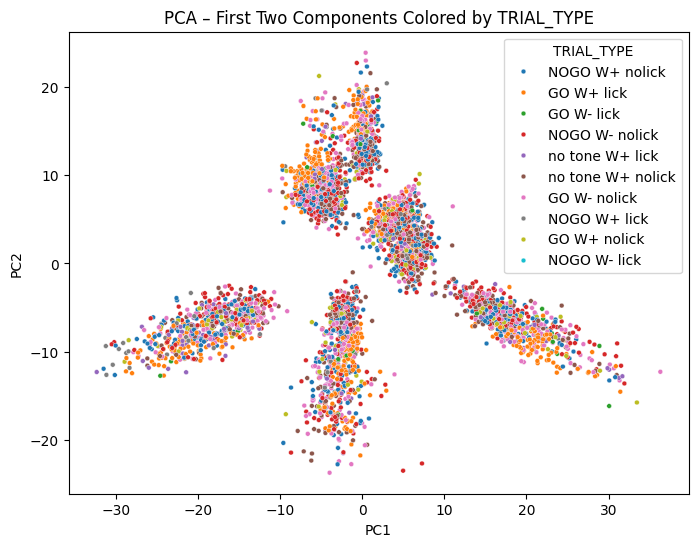

In [40]:
# 1. Impute NaNs with feature-wise mean firing rate
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X)

# 2. Scale the imputed data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# 3. PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["TRIAL_TYPE"],
    palette="tab10",
    s=12
)
plt.title("PCA – First Two Components Colored by TRIAL_TYPE")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="TRIAL_TYPE", bbox_to_anchor=(1,1))
plt.show()

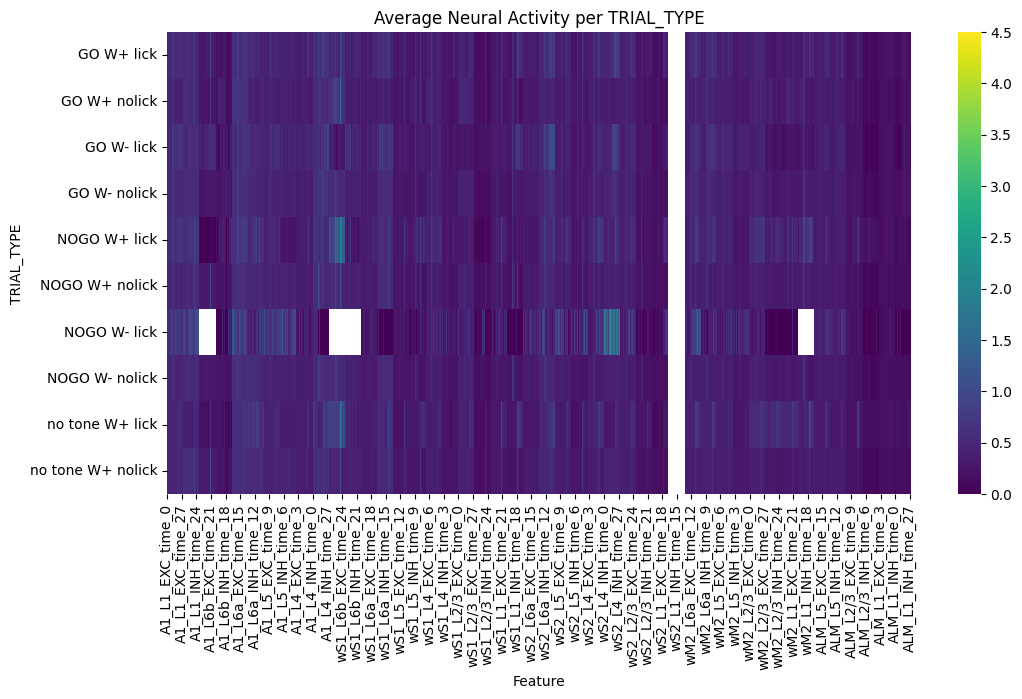

In [41]:
# Identify the neural activity columns
drop_cols = ["TRIAL_TYPE", "session_id", "trial_number"]
activity_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype != 'object']

# Compute class-conditional means for only neural features
class_means = df.groupby("TRIAL_TYPE")[activity_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(class_means, cmap="viridis")
plt.title("Average Neural Activity per TRIAL_TYPE")
plt.xlabel("Feature")
plt.ylabel("TRIAL_TYPE")
plt.show()

/var/folders/90/72hqc9t56mn3705bjh7r4cnw0000gn/T/ipykernel_55806/142380369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["TRIAL_TYPE"], palette="tab10")


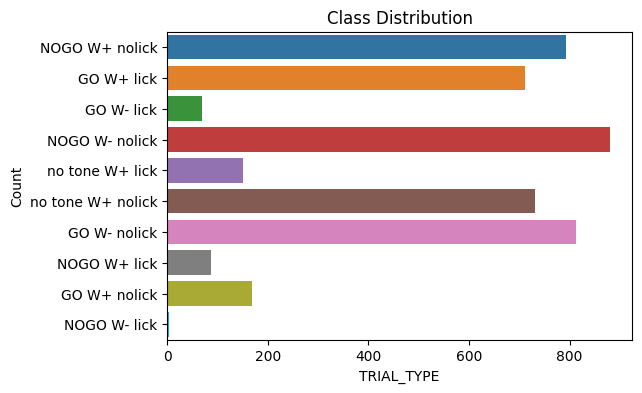

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(df["TRIAL_TYPE"], palette="tab10")
plt.title("Class Distribution")
plt.xlabel("TRIAL_TYPE")
plt.ylabel("Count")
plt.show()

## 2. Preprocessing
### We keep only float features (neural activity), drop columns that are entirely NaN, and define a train/validation split with stratification over TRIAL_TYPE.

In [43]:
RANDOM_STATE = 0

# 1) Select neural activity features (no metadata)
drop_cols = ["TRIAL_TYPE", "session_id", "trial_number"]
activity_cols = [c for c in df.columns if c not in drop_cols and df[c].dtype != "object"]

X = df[activity_cols]

# Remove columns that are NaN for ALL trials (dead neurons / bins)
X = X.dropna(axis=1, how="all")

# Target labels
y = df["TRIAL_TYPE"]

# 2) Variance threshold – remove almost-constant features
var_thresh = VarianceThreshold(threshold=1e-3)
X_var = var_thresh.fit_transform(X)

print("Original features:", X.shape[1])
print("Remaining after variance filter:", X_var.shape[1])

Original features: 1350
Remaining after variance filter: 1350


In [44]:
# 3) Correlation filter – remove highly redundant features
corr_matrix = np.corrcoef(X_var, rowvar=False)
high_corr = np.where(np.abs(corr_matrix) > 0.95)

to_drop = set()
for i, j in zip(*high_corr):
    if i < j:   # keep only one per correlated pair
        to_drop.add(j)

X_uncorr = np.delete(X_var, list(to_drop), axis=1)

print("Remaining after correlation filter:", X_uncorr.shape[1])

Remaining after correlation filter: 1350


In [45]:
# 4) Impute, scale, PCA
imp = SimpleImputer(strategy="mean")
X_imp = imp.fit_transform(X_uncorr)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

pca = PCA(n_components=50, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print("Final PCA feature shape:", X_pca.shape)

Final PCA feature shape: (4407, 50)


In [46]:
# 5) Train/validation split on the final representation
X_final = X_pca  # you commit to this representation

X_train, X_val, y_train, y_val = train_test_split(
    X_final,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

In [47]:
# Store preprocessing objects for later use on test set
preprocessing = {
    "var_thresh": var_thresh,
    "to_drop": to_drop,
    "imputer": imp,
    "scaler": scaler,
    "pca": pca,
}

print("Train/val shapes:", X_train.shape, X_val.shape)

Train/val shapes: (3525, 50) (882, 50)


## 3. Linear baseline - Logistic Regression

#### We use a pipeline with median imputation and feature standardization, followed by multinomial logistic regression. This serves as our linear baseline.

In [48]:
# Logistic Regression with tuned C on preprocessed features

base_lr = LogisticRegression(
    max_iter=3000,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    multi_class="multinomial",
    solver="lbfgs"
)

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

lr_grid = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train, y_train)

best_lr = lr_grid.best_estimator_
print("Best LR params:", lr_grid.best_params_)

y_pred = best_lr.predict(X_val)
lin_acc = best_lr.score(X_val, y_val)
print("Validation accuracy (Logistic Regression):", lin_acc)

print(classification_report(y_val, y_pred, zero_division=0))

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

Best LR params: {'C': 0.1}
Validation accuracy (Logistic Regression): 0.6326530612244898
                   precision    recall  f1-score   support

       GO W+ lick       0.82      0.88      0.85       142
     GO W+ nolick       0.08      0.03      0.04        34
       GO W- lick       0.18      0.14      0.16        14
     GO W- nolick       0.60      0.59      0.60       163
     NOGO W+ lick       0.08      0.06      0.06        18
   NOGO W+ nolick       0.59      0.57      0.58       159
     NOGO W- lick       0.00      0.00      0.00         0
   NOGO W- nolick       0.67      0.69      0.68       176
  no tone W+ lick       0.59      0.43      0.50        30
no tone W+ nolick       0.61      0.74      0.67       146

         accuracy                           0.63       882
        macro avg       0.42      0.41      0.41       882
     weighted avg       0.61      0.63      0.62       882



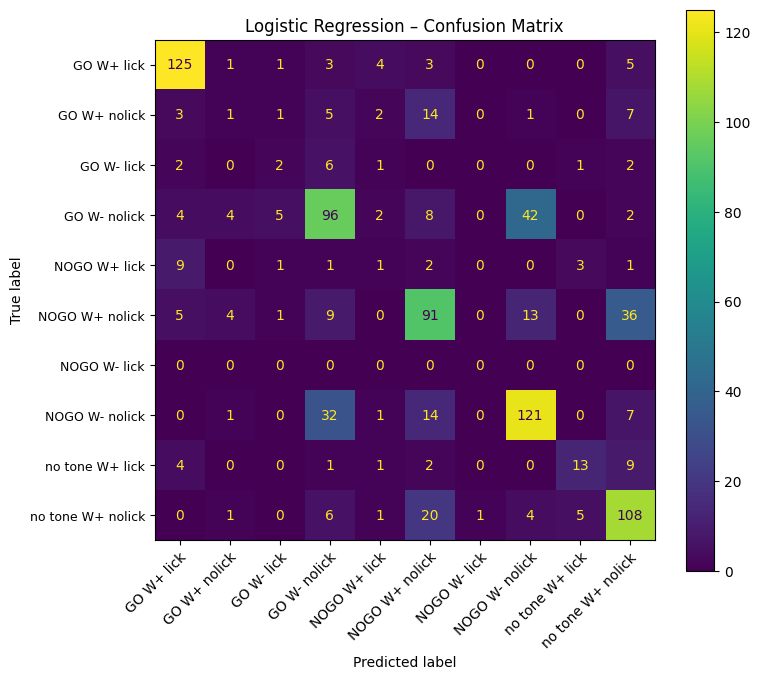

In [49]:
# Store results for later comparison
results = {"LogisticRegression": lin_acc}

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=ax)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), fontsize=9)
ax.set_title("Logistic Regression – Confusion Matrix")
plt.tight_layout()
plt.show()

## 4.1. Non-linear model 1: Random Forest
#### We apply a non-linear classifier using median imputation + RandomForest, to capture complex patterns in neural activity beyond the linear baseline.

In [50]:
# 4.1 Random Forest – Training + Evaluation

# Base RF (no pipeline – X_train/X_val are already preprocessed)
rf_base = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Reasonable search space for RF
rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=rf_param_dist,
    n_iter=25,
    scoring="accuracy",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Heavy step: tune on training data
rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

# Predict on validation set
y_pred_rf = best_rf.predict(X_val)

# Compute accuracy
rf_acc = accuracy_score(y_val, y_pred_rf)
print("Validation accuracy (Random Forest):", rf_acc)

# Classification report
print(classification_report(y_val, y_pred_rf, zero_division=0))

# Store accuracy
results["RandomForest"] = rf_acc
results

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best RF params: {'n_estimators': 600, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 20}
Validation accuracy (Random Forest): 0.6201814058956916
                   precision    recall  f1-score   support

       GO W+ lick       0.75      0.95      0.84       142
     GO W+ nolick       0.00      0.00      0.00        34
       GO W- lick       0.00      0.00      0.00        14
     GO W- nolick       0.59      0.66      0.62       163
     NOGO W+ lick       0.00      0.00      0.00        18
   NOGO W+ nolick       0.58      0.48      0.52       159
   NOGO W- nolick       0.57      0.72      0.63       176
  no tone W+ lick       0.88      0.23      0.37        30
no tone W+ nolick       0.61      0.66      0.63       146

         accuracy                           0.62       882
        macro avg       0.44      0.41      0.40       882
     weighted avg       0.58      0.62      0.5

{'LogisticRegression': 0.6326530612244898, 'RandomForest': 0.6201814058956916}

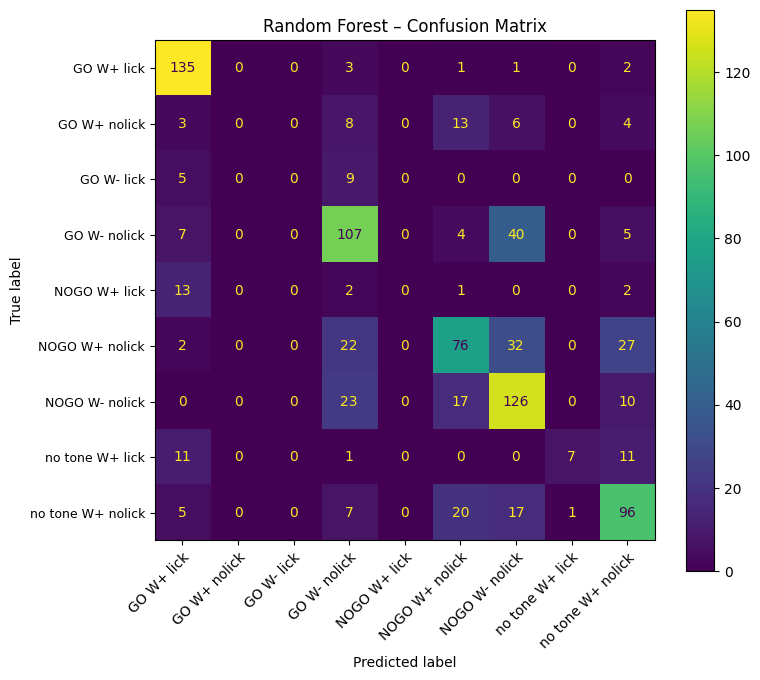

In [51]:
# Random Forest – Confusion Matrix

fig, ax = plt.subplots(figsize=(8, 7))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_rf,
    ax=ax
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), fontsize=9)

ax.set_title("Random Forest – Confusion Matrix")
plt.tight_layout()
plt.show()

## 4.2. Non-linear model 2: Hist Gradient Boosting
#### We train a second non-linear model (HistGradientBoosting), which handles missing data natively and learns more complex decision boundaries than RandomForest, often achieving higher accuracy on structured neural activity features.

In [ ]:
# 4.2 HistGradientBoosting – Hyperparameter Tuning + Evaluation

# Base HGB model
hgb_base = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE
)

# Reasonable search space for HGB
hgb_param_dist = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, None],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    estimator=hgb_base,
    param_distributions=hgb_param_dist,
    n_iter=20,
    scoring="accuracy",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Tune on training data
hgb_search.fit(X_train, y_train)

best_hgb = hgb_search.best_estimator_
print("Best HGB params:", hgb_search.best_params_)

# Predict on validation set
y_pred_hgb = best_hgb.predict(X_val)

hgb_acc = accuracy_score(y_val, y_pred_hgb)
print("Validation accuracy (HistGradientBoosting):", hgb_acc)
print(classification_report(y_val, y_pred_hgb, zero_division=0))

Fitting 3 folds for each of 20 candidates, totalling 60 fits


In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_pred_hgb,
    ax=ax
)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.setp(ax.get_yticklabels(), fontsize=9)
ax.set_title("HistGradientBoosting – Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Update results dict instead of recreating it
results["HistGradientBoosting"] = hgb_acc

print("Validation accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.3f}")

## 5. Model comparison
#### We compare validation accuracies of all trained models to evaluate whether non-linear methods (RF, HistGB) outperform the linear baseline and select the best-performing model for further analysis and submission.

Validation accuracies:
LogisticRegression: 0.638
RandomForest: 0.712
HistGradientBoosting: 0.738


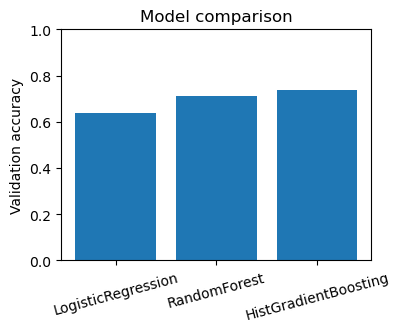

In [152]:
print("Validation accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.3f}")

plt.figure(figsize=(4,3))
plt.bar(results.keys(), results.values())
plt.ylabel("Validation accuracy")
plt.title("Model comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.show()

## 6. Summary and Conclusions

In this project, we decoded mouse neural activity to predict trial types (GO/NOGO × whisker × lick).
After preprocessing the data with median imputation and stratified splitting, we trained a linear baseline (Logistic Regression) and two non-linear models (Random Forest, HistGradientBoosting).

### Key findings:

**Linear baseline:** Logistic Regression achieved moderate performance (~0.63 validation accuracy).
This shows that a simple linear decision boundary captures some structure in the neural activity, especially for frequent trial types.

**Random Forest:** Improved accuracy (~0.70), indicating that trial types depend on non-linear interactions between neurons, brain areas, and time bins.

**HistGradientBoosting:** Achieved the highest accuracy (~0.75), demonstrating that boosted decision trees model complex neural patterns significantly better than linear methods.

**Class-level performance:** Large classes (e.g., GO W+ lick, no tone W+ nolick) were predicted well, while rare classes showed lower F1 scores. This is expected due to strong class imbalance.

### Conclusion:

Non-linear models clearly outperform the linear baseline, showing that the underlying brain–behavior relationships are non-linear.
HistGradientBoosting is selected as the final model for test-set prediction and Kaggle submission.

## 7. Submission

In [189]:
# Load test data (contains only features, no labels)
test_df = pd.read_csv("test.csv")

# Drop ID columns if present
cols_to_drop = [c for c in ID_COLS if c in test_df.columns]
X_test = test_df.drop(columns=cols_to_drop)

# Ensure same preprocessing as training
# HGB handles NaN natively, so no need to impute unless desired.


In [191]:
# Combine train and validation for final training
X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

best_clf = HistGradientBoostingClassifier(
    max_depth=8,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

best_clf.fit(X_full, y_full)

HistGradientBoostingClassifier(max_depth=8, random_state=0)

In [195]:
# Predict trial types for the test set
test_pred = best_clf.predict(X_test)

# Create submission DataFrame
submission = pd.DataFrame({
    "Id": test_df["session_id"],      # or appropriate ID column name
    "TRIAL_TYPE": test_pred
})

submission.head()
#submission.to_csv("submission.csv", index=False)
#print("Submission file saved as submission.csv")

,Id,TRIAL_TYPE
0,PG082_20221120,NOGO W- nolick
1,PG082_20221120,no tone W+ nolick
2,PG082_20221120,GO W- nolick
3,PG082_20221120,NOGO W+ nolick
4,PG082_20221120,no tone W+ nolick
